## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import threading
import asyncio
import matplotlib.pyplot as plt

LOG.propagate = False
# Get ArtemisBLEController object
ble = get_ble_controller()

def connectBLE(ble, timeout_s=10.0):
    # Fast path: already connected
    try:
        if ble.is_connected():
            return True
    except Exception:
        pass

    # Reload config ONCE (important)
    ble.reload_config()

    t0 = time.time()
    while time.time() - t0 < timeout_s:
        try:
            ble.connect()
        except Exception as e:
            # If it says already connected, treat as success
            if "already connected" in str(e).lower():
                return True

        # Give the stack a moment, then re-check
        time.sleep(0.2)
        try:
            if ble.is_connected():
                return True
        except Exception:
            pass

        time.sleep(0.3)

    raise TimeoutError("Failed to connect to BLE device")

## Connect

In [ ]:
connectBLE(ble)

## Disconnect

In [ ]:
ble.disconnect()

## Echo

In [ ]:
# Send the message
ble.send_command(CMD.ECHO, "Hello World!")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

## Send Three Floats

In [ ]:
ble.send_command(CMD.SEND_THREE_FLOATS, "3.14|5.25|7.432")

## Get Time Millis

In [ ]:
# Send command
ble.send_command(CMD.GET_TIME_MILLIS, "")

# Check board message
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

## Notification Handler

In [ ]:
def notification_callback(uuid, charac_bytearray):
    msg = ble.bytearray_to_string(charac_bytearray)
    if msg.startswith("T:"):
        t_ms = int(msg.split(":")[1])
        print("Time (ms):", t_ms)
    else:
        print("Unexpected message:", msg)

duration_s = 0.3  # set collection time

# Set up callback
ble.start_notify(ble.uuid['RX_STRING'], notification_callback)

t0 = time.time()
while (time.time() - t0) < duration_s:
    time.sleep(0.01)   # small sleep so you don't busy-wait

ble.stop_notify(ble.uuid['RX_STRING'])
print("End time notify")




## Time Array

In [ ]:
done = threading.Event()
time_values = []

def time_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    if parts and parts[-1].lower() == "end":
        time_values.extend(parts[:-1])
        print("End of values")
        done.set()
        return
    time_values.extend(parts)

def get_time_data(timeout_s=10.0):
    time_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.SEND_TIME_DATA, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(time_values)

# start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], time_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
time.sleep(0.2)

vals = get_time_data()
print(vals)

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


## Temp Readings

In [ ]:
done = threading.Event()
time_values = []
temp_values = []

def temp_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    for token in parts:
        if token.lower() == "end":
            print("End of values")
            done.set()
            return

        try:
            time_str, t_str = token.split(":", 1)
            temp_values.append(int(t_str))
            time_values.append(int(time_str))
        except ValueError:
            print("Bad token:", repr(token))

def get_temp_data(timeout_s=10.0):
    time_values.clear()
    temp_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.GET_TEMP_READINGS, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(temp_values), list(time_values)

# start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], temp_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
time.sleep(0.2)

temp_vals, time_vals = get_temp_data()

print("Temp array length: ", len(temp_values))
print("Time array length: ", len(time_values))
print("Temp values: ",temp_vals)
print("Time values:", time_vals)

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


## Data Rate

In [ ]:
# Code generated by AI
msg_sizes = [5, 10, 25, 50, 100, 120]
transmit_times = {}
received_data = []

def data_rate_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    rx_time = time.perf_counter()
    size = len(msg)
    received_data.append((rx_time, size))
    print(f"Callback: len={size}")

# Start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], data_rate_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")

time.sleep(1.0)
received_data.clear()

# Send all requests, recording transmit times by size
for size in msg_sizes:
    print(f"Sending request for {size} bytes...")
    transmit_times[size] = time.perf_counter()
    ble.send_command(CMD.DATA_RATE, str(size))
    time.sleep(0.1)  # Short delay between sends

# Send a dummy request immediately to flush the last real response
print("Sending dummy request to flush...")
ble.send_command(CMD.DATA_RATE, "1")
time.sleep(1.0)  # Wait for all responses

# Stop notifications
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications")

# Debug output
print(f"\nReceived {len(received_data)} responses")
for rx_time, size in received_data:
    print(f"  Size: {size}")

# Match received responses to transmit times by size
# Filter out the dummy response (size 1)
results = []
for rx_time, size in received_data:
    if size in transmit_times and size in msg_sizes:
        rtt = rx_time - transmit_times[size]
        results.append((size, rtt))

# Sort by size
results.sort(key=lambda x: x[0])

# Display results
print("\n--- Data Rate Results ---")
actual_sizes = []
round_trip_times = []
data_rates = []

for size, rtt in results:
    one_way = rtt / 2
    rate = size / one_way
    actual_sizes.append(size)
    round_trip_times.append(rtt * 1000)
    data_rates.append(rate)
    print(f"{size:3d} bytes: RTT = {rtt*1000:.2f} ms, "
          f"One-way = {one_way*1000:.2f} ms, "
          f"Data rate = {rate:.2f} bytes/sec")

# Plot
if len(results) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(actual_sizes, round_trip_times, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Message Size (bytes)')
    ax1.set_ylabel('Round-Trip Time (ms)')
    ax1.set_title('Round-Trip Time vs Message Size')
    ax1.grid(True)

    ax2.plot(actual_sizes, data_rates, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Message Size (bytes)')
    ax2.set_ylabel('Data Rate (bytes/sec)')
    ax2.set_title('Data Rate vs Message Size')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('ble_data_rate.png')
    plt.show()

### IMU Data

In [ ]:
done = threading.Event()
time_values = []
imu_values = []

def imu_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    #print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    for token in parts:
        if token.lower() == "end":
            print("End of values")
            done.set()
            return

        try:
            time_str, pitch_str, roll_str, yaw_str = token.split(":", 3)
            imu_values.append([float(pitch_str), float(roll_str), float(yaw_str)])
            time_values.append(int(time_str))
        except ValueError:
            print("Bad token:", repr(token))

def get_imu_data(timeout_s=40.0):
    time_values.clear()
    imu_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.GET_IMU_READINGS, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(imu_values), list(time_values)



# start notify
try:
    connectBLE(ble)
    
    ble.start_notify(ble.uuid['RX_STRING'], imu_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
    else:
        raise
time.sleep(0.2)

imu_vals, time_vals = get_imu_data()

print("IMU array length: ", len(imu_values))
print("Time array length: ", len(time_values))
#print("IMU values: ",imu_vals)
#print("Time values:", time_vals)

t = np.array(time_vals, dtype=np.int64)

# if time_vals are in milliseconds:
dt = np.diff(t)              # dt in ms
ave_dt = dt.mean()           # average dt in ms
sample_rate_hz = 1000.0 / ave_dt
recording_time = (time_vals[-1] - time_vals[0]) / 1000 # Convert from ms to s

print(f"Average dt: {ave_dt:.2f} ms")
print("Recording time: ", recording_time, "s")

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


### Start recording

In [125]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

ble.send_command(CMD.START_RECORDING, "")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

2026-03-08 21:15:31,183 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:d1:79:ab:49
2026-03-08 21:15:31,184 | INFO     |: Scanning for device with address: c0:42:d1:79:ab:49, service UUID: 4843fd62-068c-4a37-af34-e724c6a05681
2026-03-08 21:15:41,311 | INFO     |: Found 72 total devices
2026-03-08 21:15:41,314 | INFO     |: Found matching device: C0:42:D1:79:AB:49 (name: Artemis BLE)
2026-03-08 21:15:43,415 | INFO     |: Connected to c0:42:d1:79:ab:49
Recieved from board: Started recording


### Stop Recording

In [77]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

ble.send_command(CMD.STOP_RECORDING, "")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

2026-03-08 21:01:55,927 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:d1:79:ab:49
2026-03-08 21:01:55,928 | INFO     |: Scanning for device with address: c0:42:d1:79:ab:49, service UUID: 4843fd62-068c-4a37-af34-e724c6a05681
2026-03-08 21:02:06,065 | INFO     |: Found 68 total devices
2026-03-08 21:02:06,067 | INFO     |: Found matching device: C0:42:D1:79:AB:49 (name: Artemis BLE)
2026-03-08 21:02:07,296 | INFO     |: Connected to c0:42:d1:79:ab:49
Recieved from board: Stopped recording


### Get Distance Data

End of values
Dist array length:  2000
Time array length:  2000
Average dt: 5.45 ms
Recording time:  10.891 s


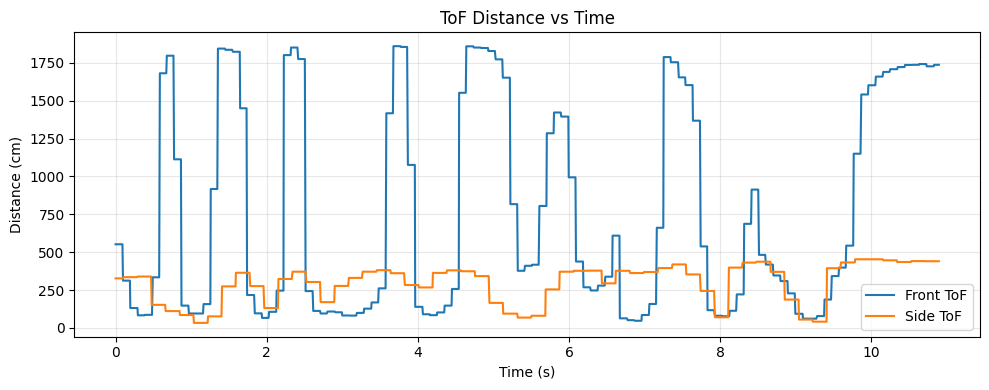

In [26]:
done = threading.Event()
time_values = []
dist_values = []

def dist_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    #print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    for token in parts:
        if token.lower() == "end":
            print("End of values")
            done.set()
            return

        try:
            time_str, front_str, side_str = token.split(":", 2)
            dist_values.append([int(front_str), int(side_str)])
            time_values.append(int(time_str))
        except ValueError:
            print("Bad token:", repr(token))

def get_dist_data(timeout_s=40.0):
    time_values.clear()
    dist_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.GET_DIST_READINGS, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(dist_values), list(time_values)



# start notify
try:
    connectBLE(ble)
    
    ble.start_notify(ble.uuid['RX_STRING'], dist_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
    else:
        raise
time.sleep(0.2)

dist_vals, time_vals = get_dist_data()

print("Dist array length: ", len(dist_values))
print("Time array length: ", len(time_values))
#print("Dist values: ",dist_vals)
#print("Time values:", time_vals)

t = np.array(time_vals, dtype=np.int64)

# if time_vals are in milliseconds:
dt = np.diff(t)              # dt in ms
ave_dt = dt.mean()           # average dt in ms
sample_rate_hz = 1000.0 / ave_dt
recording_time = (time_vals[-1] - time_vals[0]) / 1000 # Convert from ms to s

print(f"Average dt: {ave_dt:.2f} ms")
print("Recording time: ", recording_time, "s")

# --- Plot two ToF sensors over time ---

# Convert to numpy
t_ms = np.array(time_vals, dtype=np.int64)
d = np.array(dist_vals, dtype=np.int32)   # shape (N, 2): [front, side]

# Basic sanity check
if t_ms.size == 0 or d.size == 0:
    raise RuntimeError("No data received (time_vals/dist_vals empty).")
if d.ndim != 2 or d.shape[1] != 2:
    raise RuntimeError(f"dist_vals has unexpected shape: {d.shape}")

front_cm = d[:, 0]
side_cm  = d[:, 1]

# Convert time to seconds and start at 0
t_s = (t_ms - t_ms[0]) / 1000.0

plt.figure(figsize=(10, 4))
plt.plot(t_s, front_cm, label="Front ToF")
plt.plot(t_s, side_cm,  label="Side ToF")
plt.xlabel("Time (s)")
plt.ylabel("Distance (cm)")
plt.title("ToF Distance vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


### Collect All Data

End of values
IMU array length:  2000
Dist array length:  2000
Motor array length:  2000
Time array length:  2000
Time values: [58185, 58194, 58199, 58203, 58207, 58212, 58216, 58224, 58233, 58237, 58247, 58256, 58265, 58274, 58277, 58286, 58290, 58294, 58298, 58303, 58311, 58315, 58321, 58330, 58334, 58344, 58350, 58359, 58366, 58370, 58376, 58385, 58389, 58393, 58401, 58405, 58413, 58421, 58425, 58434, 58440, 58445, 58449, 58453, 58458, 58462, 58470, 58479, 58483, 58491]
Average dt: 9.30 ms
Recording time:  18.592 s
Average dt: 9.30 ms
Sample rate: 107.52 Hz
Recording time: 18.592 s


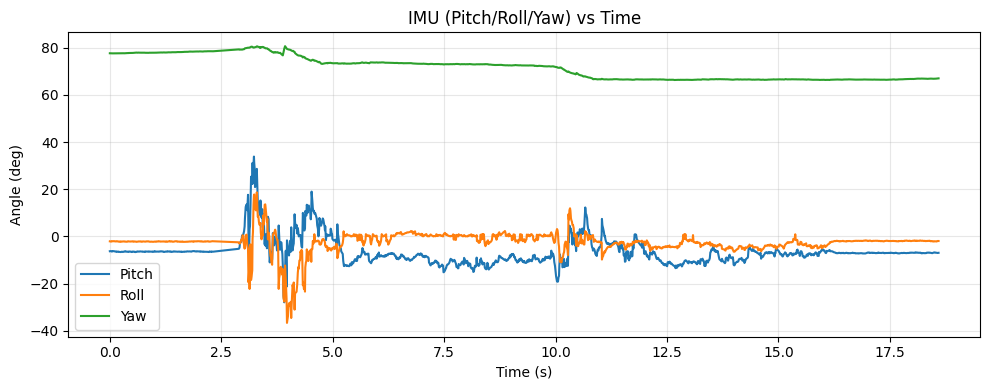

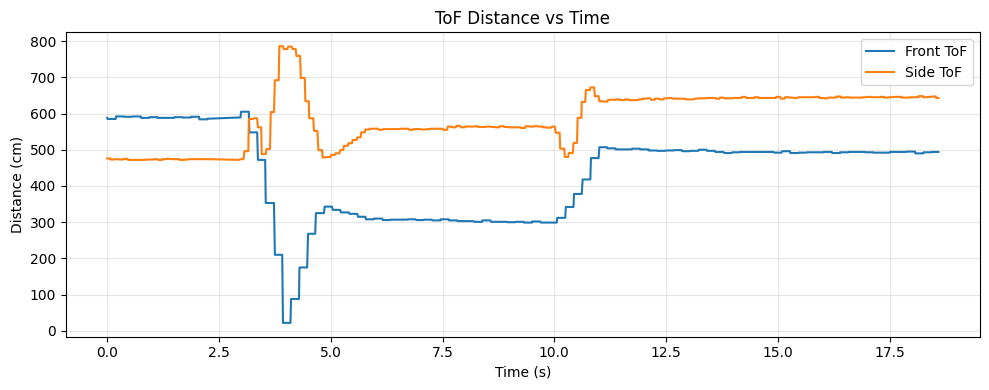

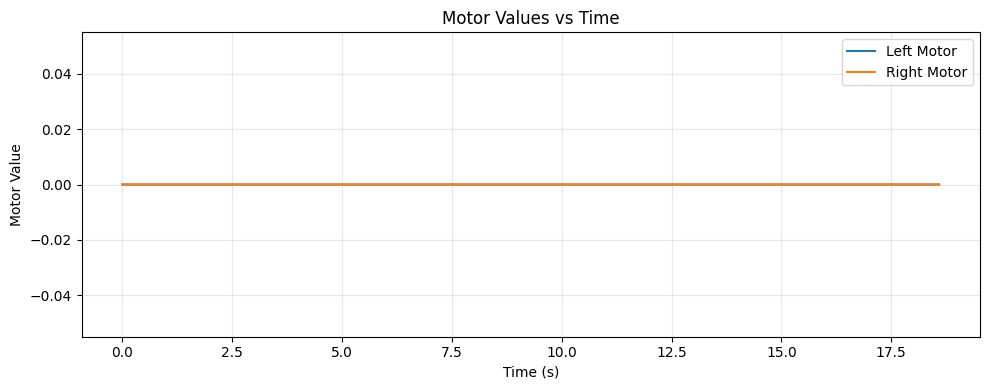

In [131]:
done = threading.Event()
time_values = []
dist_values = []
imu_values = []
motor_values = []

def all_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    #print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    for token in parts:
        if token.lower() == "end":
            print("End of values")
            done.set()
            return

        try:
            time_str, pitch_str, roll_str, yaw_str, front_str, side_str, left_mot_str, right_mot_str = token.split(":", 7)
            imu_values.append([float(pitch_str), float(roll_str), float(yaw_str)])
            dist_values.append([int(front_str), int(side_str)])
            motor_values.append([float(left_mot_str), float(right_mot_str)])
            time_values.append(int(time_str))
        except ValueError:
            print("Bad token:", repr(token))

def get_all_data(timeout_s=60.0):
    time_values.clear()
    dist_values.clear()
    imu_values.clear()
    motor_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.GET_ALL_READINGS, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(imu_values), list(dist_values), list(motor_values), list(time_values)



# start notify
try:
    connectBLE(ble)
    
    ble.start_notify(ble.uuid['RX_STRING'], all_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
    else:
        raise
time.sleep(0.2)

imu_vals, dist_vals, motor_values, time_vals = get_all_data()

print("IMU array length: ", len(imu_values))
print("Dist array length: ", len(dist_values))
print("Motor array length: ", len(motor_values))
print("Time array length: ", len(time_values))
#print("Dist values: ",dist_vals)
print("Time values:", time_vals[-50:])

t = np.array(time_vals, dtype=np.int64)

# if time_vals are in milliseconds:
dt = np.diff(t)              # dt in ms
ave_dt = dt.mean()           # average dt in ms
sample_rate_hz = 1000.0 / ave_dt
recording_time = (time_vals[-1] - time_vals[0]) / 1000 # Convert from ms to s

print(f"Average dt: {ave_dt:.2f} ms")
print("Recording time: ", recording_time, "s")

# --- Basic timing stats ---
t_ms = np.array(time_vals, dtype=np.int64)
if t_ms.size < 2:
    raise RuntimeError("Not enough samples to compute dt / plot.")

dt = np.diff(t_ms)                  # dt in ms
ave_dt = dt.mean()                  # average dt in ms
sample_rate_hz = 1000.0 / ave_dt
recording_time = (t_ms[-1] - t_ms[0]) / 1000.0

print(f"Average dt: {ave_dt:.2f} ms")
print(f"Sample rate: {sample_rate_hz:.2f} Hz")
print("Recording time:", recording_time, "s")

# Convert time to seconds starting at 0
t_s = (t_ms - t_ms[0]) / 1000.0

# --- Convert data arrays ---
imu = np.array(imu_vals, dtype=np.float32)   # shape (N, 3): pitch, roll, yaw
d   = np.array(dist_vals, dtype=np.int32)    # shape (N, 2): front, side

# Sanity checks
if imu.ndim != 2 or imu.shape[1] != 3:
    raise RuntimeError(f"imu_vals has unexpected shape: {imu.shape}")
if d.ndim != 2 or d.shape[1] != 2:
    raise RuntimeError(f"dist_vals has unexpected shape: {d.shape}")
if len(t_s) != len(imu) or len(t_s) != len(d):
    raise RuntimeError(f"Length mismatch: t={len(t_s)}, imu={len(imu)}, dist={len(d)}")

pitch = imu[:, 0]
roll  = imu[:, 1]
yaw   = imu[:, 2]

front_cm = d[:, 0]
side_cm  = d[:, 1]

# --- Plot IMU over time ---
plt.figure(figsize=(10, 4))
plt.plot(t_s, pitch, label="Pitch")
plt.plot(t_s, roll,  label="Roll")
plt.plot(t_s, yaw,   label="Yaw")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")  # change if your IMU data isn't degrees
plt.title("IMU (Pitch/Roll/Yaw) vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot ToF over time ---
plt.figure(figsize=(10, 4))
plt.plot(t_s, front_cm, label="Front ToF")
plt.plot(t_s, side_cm,  label="Side ToF")
plt.xlabel("Time (s)")
plt.ylabel("Distance (cm)")
plt.title("ToF Distance vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Motor values over time ---
m = np.array(motor_values)

left_mot = m[:, 0]
right_mot = m[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(t_s, left_mot, label="Left Motor")
plt.plot(t_s, right_mot, label="Right Motor")
plt.xlabel("Time (s)")
plt.ylabel("Motor Value")
plt.title("Motor Values vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


### Set Motor Job

In [70]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

#left, right, duration
ble.send_command(CMD.SET_MOTOR_JOB, "43.85|30|1700") # 17 is min from start for forwards

#+-40 was what I needed to get it to spin in place
#I found that I needed something like 70, 30 to really get it to turn while going forward
# final calibration is 43.85/30

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

2026-03-03 00:20:00,398 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:d1:79:ab:49
2026-03-03 00:20:00,412 | INFO     |: Scanning for device with address: c0:42:d1:79:ab:49, service UUID: 4843fd62-068c-4a37-af34-e724c6a05681
2026-03-03 00:20:10,552 | INFO     |: Found 26 total devices
2026-03-03 00:20:10,553 | INFO     |: Found matching device: C0:42:D1:79:AB:49 (name: Artemis BLE)
2026-03-03 00:20:11,892 | INFO     |: Connected to c0:42:d1:79:ab:49
Recieved from board: Robot recieved: l:43.849998,r:30.000000,d:1700


### Set Motor Sequence

In [8]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

#sequence = ["0|0|4000","43.85|30|2700", "30|-30|1300"] turning sequence
sequence = ["0|0|4000","43.85|30|700", "25|15|3500"]

sequence_string = "|".join(sequence)

#left, right, duration
ble.send_command(CMD.SET_MOTOR_SEQUENCE, sequence_string) # 17 is min from start for forwards

#+-40 was what I needed to get it to spin in place
#I found that I needed something like 70, 30 to really get it to turn while going forward
# final calibration is 43.85/30

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

Recieved from board: Queued 3 motor jobs


### Set PID Values

In [126]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

sequence = "0.2|0.007|0.07|0.5"

ble.send_command(CMD.SET_PID_VALUES, sequence) 

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

Recieved from board: Robot received: p:0.200000,i:0.007000,d:0.070000, w_m:0.500000


### Set Setpoint

In [129]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

# Setpoint in cm
sequence = "50"

ble.send_command(CMD.SET_SETPOINT, sequence) 

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

Recieved from board: Robot received: sp:50.000000


### Start PID

In [128]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

ble.send_command(CMD.START_PID, "")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

Recieved from board: Starting PID control


### Stop PID

In [130]:
# Send the message

try:
    connectBLE(ble)
except Exception as e:
    print("Exception")

ble.send_command(CMD.STOP_PID, "")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

Recieved from board: Stopping PID control
